# Supercooling in the Model Output

The degree of supercooling is given by

$$ \Delta T_{SC} = T_F - T $$


We distinguish between 
- **model potential supercooling**: with $T_F$ as the (constant) model freezing point -1.9
- **physical potential supercooling**: with $T=T_{pot}$ and $T_F = T_F(p=0,S)$ (physical surface-referenced freezing point)
- **in-situ supercooling**: with $T=T_{in-situ}$ and $T_F = T_F(p,S)$ (physical in-situ freezing point)

## Import Packages & Load Data

In [2]:
# packages for data processing
import numpy as np
import pandas as pd
import xarray as xr
from xmitgcm import open_mdsdataset
import gsw as gsw

# packages for plotting
import matplotlib.pyplot as plt
import plotly.graph_objects as go # interactive/3D plotting
import plotly.express as px
import cmocean.cm as cmo # ocean colormaps

# my own plotting functions
from plotting_functions import *

# technical packages
import warnings

In [3]:
model_run = "MIZ002"
delta_t = 4 # time step in seconds
output_dir = "../../MITgcm/so_plumes/" + model_run

# surpress the xmitgcm warning about future changes with timedelta
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)

    # open dataset
    ds = open_mdsdataset(output_dir, prefix = ['Eta', 'U', 'W', 'T', 'V', 'S', 'PH'], delta_t = delta_t, geometry = "cartesian")
print(ds["T"].min().values)

-2.0005


In [4]:
ds

<xarray.Dataset> Size: 227MB
Dimensions:  (XC: 50, YC: 100, XG: 50, YG: 100, Z: 50, Zp1: 51, Zu: 50, Zl: 50,
              time: 37)
Coordinates: (12/37)
  * XC       (XC) >f4 200B 2.0 6.0 10.0 14.0 18.0 ... 186.0 190.0 194.0 198.0
  * YC       (YC) >f4 400B 2.0 6.0 10.0 14.0 18.0 ... 386.0 390.0 394.0 398.0
  * XG       (XG) >f4 200B 0.0 4.0 8.0 12.0 16.0 ... 184.0 188.0 192.0 196.0
  * YG       (YG) >f4 400B 0.0 4.0 8.0 12.0 16.0 ... 384.0 388.0 392.0 396.0
  * Z        (Z) >f4 200B -0.5 -1.55 -2.7 -3.9 ... -166.9 -175.9 -185.1 -194.9
  * Zp1      (Zp1) >f4 204B 0.0 -1.0 -2.1 -3.3 ... -171.3 -180.4 -189.9 -199.9
    ...       ...
    rhoRef   (Z) >f4 200B dask.array<chunksize=(50,), meta=np.ndarray>
    dyF      (YC, XC) >f4 20kB dask.array<chunksize=(100, 50), meta=np.ndarray>
    dyU      (YG, XG) >f4 20kB dask.array<chunksize=(100, 50), meta=np.ndarray>
    maskInW  (YC, XG) bool 5kB dask.array<chunksize=(100, 50), meta=np.ndarray>
    dxF      (YC, XC) >f4 20kB dask.array<chunksize=(100, 50), meta=np.ndarray>
    iter     (time) int64 296B dask.array<chunksize=(1,), meta=np.ndarray>
Data variables:
    Eta      (time, YC, XC) float32 740kB dask.array<chunksize=(1, 100, 50), meta=np.ndarray>
    W        (time, Zl, YC, XC) float32 37MB dask.array<chunksize=(1, 50, 100, 50), meta=np.ndarray>
    U        (time, Z, YC, XG) float32 37MB dask.array<chunksize=(1, 50, 100, 50), meta=np.ndarray>
    S        (time, Z, YC, XC) float32 37MB dask.array<chunksize=(1, 50, 100, 50), meta=np.ndarray>
    T        (time, Z, YC, XC) float32 37MB dask.array<chunksize=(1, 50, 100, 50), meta=np.ndarray>
    PH       (time, Z, YC, XC) float32 37MB dask.array<chunksize=(1, 50, 100, 50), meta=np.ndarray>
    V        (time, Z, YG, XC) float32 37MB dask.array<chunksize=(1, 50, 100, 50), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(data_dir='../../MITgcm/...

## Model Potential Supercooling

To calculate the model potential supercooling we only need the (constant) model freezing point `Tfreezing` and the potential temperature, which is already included in the model output.

In [5]:
Tfreezing = -1.9
ds["modelSC"] = (Tfreezing-ds["T"])
ds["modelSC"].attrs["standard_name"] = "model_supercooling"
ds["modelSC"].attrs["long_name"] = "Model Supercooling"
ds["modelSC"].attrs["units"] = "degrees_Celsius"

## Physical Potential Supercooling

To calculate the physical potential supercooling we need the surface freezing point and the potential temperature, which is already included in the model output.

In [6]:
Tfreezing_p0 = gsw.t_freezing(ds["S"], 0, 0)
ds["potSC"] = (Tfreezing_p0-ds["T"])
ds["potSC"].attrs["standard_name"] = "potential_supercooling"
ds["potSC"].attrs["long_name"] = "Potential Supercooling"
ds["potSC"].attrs["units"] = "degrees_Celsius"


## In-Situ Supercooling

To calculate the in-situ supercooling we need to first calculate
- the in situ temperature
- the in-situ freezing point

In-situ temperature:



In [7]:
# conservative temperature
ds["CT"] = gsw.CT_from_pt(ds["S"], ds["T"])
# calculate sea pressure
ds["p"] = ds["PH"] + ds["PHrefC"]
ds["T_situ"]=gsw.t_from_CT(ds["S"], ds["CT"], ds["p"])

In [8]:
# freezing point
ds["T_f"] = gsw.t_freezing(ds["S"], ds["p"], 0) # what about oxygen saturation fraction?

# in situ supercooling
ds["insituSC"] = ds["T_f"] - ds["T_situ"]
ds["insituSC"].attrs["standard_name"] = "in_situ_supercooling"
ds["insituSC"].attrs["long_name"] = "In Situ Supercooling"
ds["insituSC"].attrs["units"] = "degrees_Celsius"

if this gets slow: `gsw.t_freezing_poly(SA, p, saturation_fraction)` is a faster implementation that should still be accurate enough (see gsw documentation)

## Plot Whole Domain

In [34]:
# monodirectional colormap (we set cmin=0 for this)
var = "insituSC"
fig = cube_time_evol(ds, var, model_run, colorscale="ice_r", grid=False)

filename = "animation_" + model_run + "_" + var + "_wholedomain_" + ".html"
fig.write_html(filename)
print(filename)
# fig.show(renderer="browser") # works in vscode, not in jupyterhub

animation_MIZ002_insituSC_wholedomain_.html


## Plot North-South Crosssection

In [13]:
len(ds.XC)

50

In [9]:
ds.insituSC.dims

('time', 'Z', 'YC', 'XC')

In [10]:
# monodirectional colormap (we set cmin=0 for this)
var = "insituSC"
xdim = ds[var].dims[3]
ydim = ds[var].dims[2]
zdim = ds[var].dims[1]

half = int(len(ds.XC)/2)
fig = cube_time_evol(ds.isel(XC = slice(0,half)), var, xdim, ydim, zdim, model_run, colorscale="ice_r", grid=False)

filename = "animation_" + model_run + "_" + var + "_N-S-crossection_" + ".html"
fig.write_html(filename)
print(filename)
# fig.show(renderer="browser") # works in vscode, not in jupyterhub

animation_MIZ002_insituSC_N-S-crossection_.html


## Plot Lead View

In [33]:
# crop to lead view
x_min = 0.0
x_max = 1190.0
mask = (ds["XC"] >= x_min) & (ds["XC"] <= x_max)
ds_sub = ds.where(mask, drop=True)

In [9]:
print("Max. model supercooling: ", ds_sub["modelSC"].max().values)
print("Max. potential supercooling: ", ds_sub["potSC"].max().values)
print("Max. in situ supercooling: ", ds_sub["insituSC"].max().values)

Max. model supercooling:  0.10049999
Max. potential supercooling:  0.1387260301702784
Max. in situ supercooling:  0.1348812003505797


In [10]:
# monodirectional colormap (we set cmin=0 for this)
var = "modelSC"
xdim = ds[var].dims[3]
ydim = ds[var].dims[2]
zdim = ds[var].dims[1]

fig = cube_time_evol(ds_sub, var, xdim, ydim, zdim, model_run, colorscale="ice_r", grid=False)

filename = "animation_" + model_run + "_" + var + "_" + ".html"
fig.write_html(filename)
print(filename)
# fig.show(renderer="browser") # works in vscode, not in jupyterhub

animation_MSL008_modelSC_.html


## Supercooling Time Series

In [34]:
ds_lead = ds.isel(XC=slice(285, 310)) # or .sel with slice(1142, 1238) in terms of physical coordinates
ds_lead_mean = ds_lead.mean(dim = ["XC", "YC", "XG","YG"])

In [10]:
ds_lead_mean.insituSC.values

array([[-3.86328069e-03, -1.15728473e-02, -1.92877985e-02, ...,
        -5.47952591e+00, -5.57205144e+00, -5.66943607e+00],
       [ 2.96845280e-02,  5.44098382e-03, -7.20336554e-03, ...,
        -5.47952362e+00, -5.57204787e+00, -5.66943769e+00],
       [ 3.55273112e-02,  8.61844577e-03, -4.83972492e-03, ...,
        -5.47952654e+00, -5.57204670e+00, -5.66944064e+00],
       ...,
       [ 1.34420192e-01,  7.01112760e-02,  4.81009790e-02, ...,
        -5.47950043e+00, -5.57122486e+00, -5.67057270e+00],
       [ 1.34466190e-01,  8.13605748e-02,  5.84557786e-02, ...,
        -5.47905690e+00, -5.57093388e+00, -5.67061515e+00],
       [ 8.53509852e-02,  5.54249986e-02,  4.93628774e-02, ...,
        -5.47907946e+00, -5.57097721e+00, -5.67067852e+00]],
      shape=(19, 99))

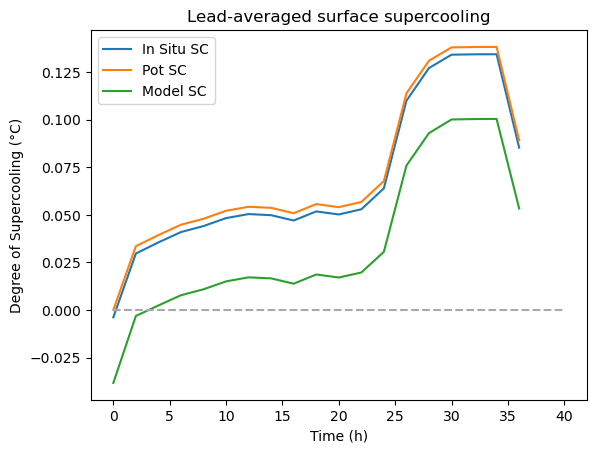

In [13]:
# plot supercooling

plot = False # it takes a while to run this
if plot:
    plt.plot(ds_lead_mean.time/(60*60*1e9), ds_lead_mean.insituSC.isel(Z=0), label = "In Situ SC")
    plt.plot(ds_lead_mean.time/(60*60*1e9), ds_lead_mean.potSC.isel(Z=0), label = "Pot SC")
    plt.plot(ds_lead_mean.time/(60*60*1e9), ds_lead_mean.modelSC.isel(Z=0), label = "Model SC")
    
    plt.ylabel("Degree of Supercooling (°C)")
    plt.xlabel("Time (h)")
    plt.title("Lead-averaged surface supercooling")
    plt.hlines(0,0,40, linestyle ="dashed", color = "darkgrey")

    plt.legend()

## Depth Statistics

I want to create a plot that shows 
- the percentage of supercooled cells
- the average degree of supercooling withing those

for each depth within the lead.

In [37]:
# crop dataset to upper ocean
ds_lead_upper = ds_lead.sel(Z=slice(-0.5,-201.))

In [16]:
ds_lead_upper = ds

In [23]:
SC_depth_stats = xr.Dataset() # dataset to save depth averages and fractions

SCvars = ["insituSC", "potSC", "modelSC"] 
dims_to_reduce = ["time", "XC", "YC"] # reduce/average along these dims

for var in SCvars:
    data = ds_lead_upper[var]
    
    # Create a boolean mask for positive values
    is_positive = data > 0.0005
    
    # Fraction of positive values: Mean of the boolean mask (True=1, False=0)
    frac = is_positive.mean(dim=dims_to_reduce)*100
    
    # Average of positive values: Mask negatives to NaN, then take mean
    mean_positive = data.where(is_positive).mean(dim=dims_to_reduce)
    
    # Add both results to the existing dataset with descriptive names
    SC_depth_stats[f"{var}_frac"] = frac
    SC_depth_stats[f"{var}_mean_positive"] = mean_positive

# saving takes a while, but is necessary for continuing
# the calculations are only performed when the data is needed for saving or plotting or similar
save = True 
if save:
    filename = model_run + "_SC_depth_stats.nc"
    SC_depth_stats.to_netcdf(filename)
    print("SC_depth_stats saved to "+filename)
else:
   print("SC_depth_stats not saved") 
SC_depth_stats

sh: getfattr: command not found


SC_depth_stats saved to MIZ002_SC_depth_stats.nc


<xarray.Dataset> Size: 3kB
Dimensions:                 (Z: 50)
Coordinates:
  * Z                       (Z) >f4 200B -0.5 -1.55 -2.7 ... -185.1 -194.9
    drF                     (Z) >f4 200B dask.array<chunksize=(50,), meta=np.ndarray>
    PHrefC                  (Z) >f4 200B dask.array<chunksize=(50,), meta=np.ndarray>
    rhoRef                  (Z) >f4 200B dask.array<chunksize=(50,), meta=np.ndarray>
Data variables:
    insituSC_frac           (Z) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
    insituSC_mean_positive  (Z) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
    potSC_frac              (Z) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
    potSC_mean_positive     (Z) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
    modelSC_frac            (Z) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
    modelSC_mean_positive   (Z) float32 200B dask.array<chunksize=(50,), meta=np.ndarray>

sh: getfattr: command not found


Text(0.5, 0.98, 'Depth Statistics of Supercooling in the Simulated Lead\nMIZ002')

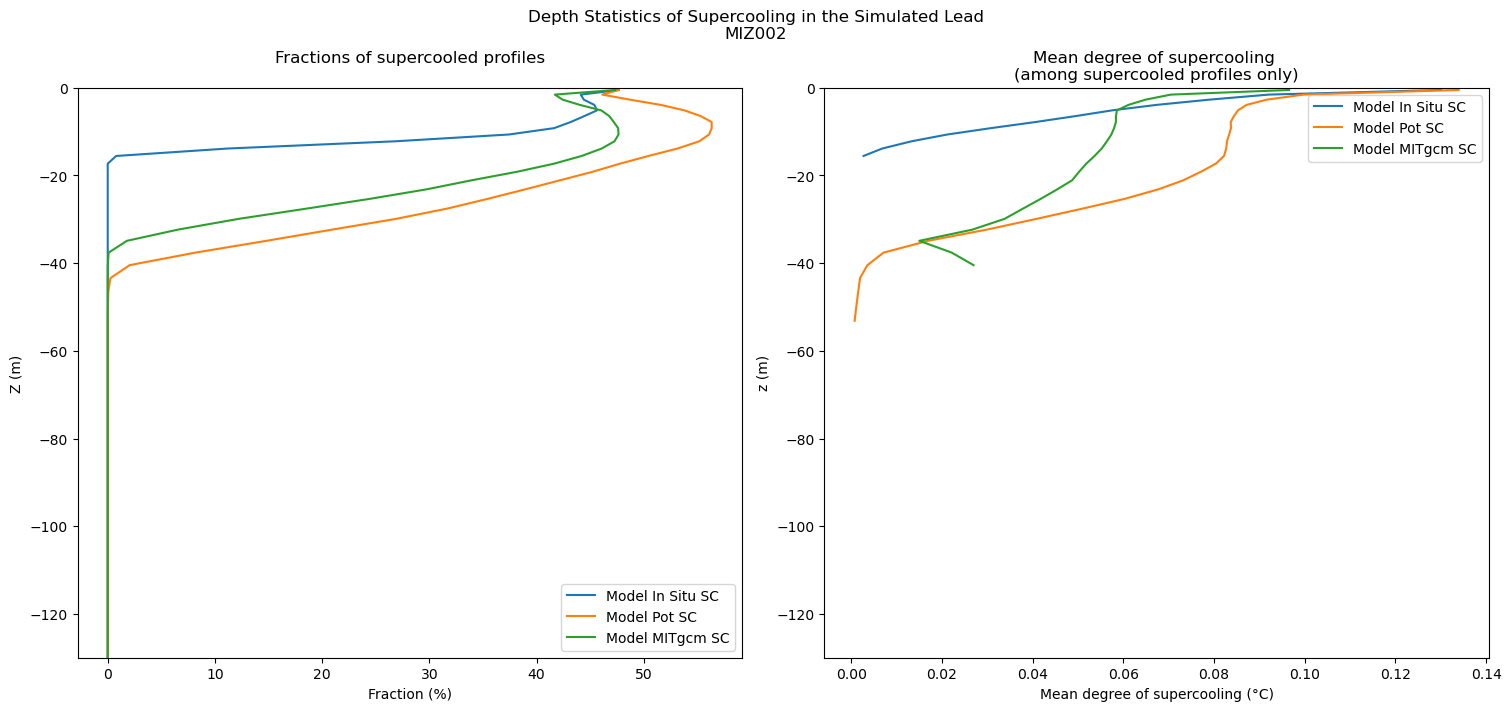

In [24]:
# Plot
filename = model_run + "_SC_depth_stats.nc"
SC_depth_stats = xr.open_dataset(filename)

fig, ax = plt.subplots(1,2, figsize = (15,7), layout = "constrained")

# Plot Supercooling Fractions
ax[0].plot(SC_depth_stats.insituSC_frac, SC_depth_stats.Z, label = "Model In Situ SC")
ax[0].plot(SC_depth_stats.potSC_frac, SC_depth_stats.Z, label = "Model Pot SC")
ax[0].plot(SC_depth_stats.modelSC_frac, SC_depth_stats.Z, label = "Model MITgcm SC")

ax[0].set_xlabel("Fraction (%)")
ax[0].set_ylabel("Z (m)")
ax[0].set_title("Fractions of supercooled profiles\n")


# plot mean supercooling
ax[1].plot(SC_depth_stats.insituSC_mean_positive, SC_depth_stats.Z, label = "Model In Situ SC")
ax[1].plot(SC_depth_stats.potSC_mean_positive, SC_depth_stats.Z, label = "Model Pot SC")
ax[1].plot(SC_depth_stats.modelSC_mean_positive, SC_depth_stats.Z, label = "Model MITgcm SC")

ax[1].set_xlabel("Mean degree of supercooling (°C)")
ax[1].set_ylabel("z (m)")
ax[1].set_title("Mean degree of supercooling \n(among supercooled profiles only)")



for a in ax:
    a.set_ylim(-130,0)

ax[0].legend()
ax[1].legend()

plt.suptitle(f"Depth Statistics of Supercooling in the Simulated Lead\n{model_run}")

sh: getfattr: command not found


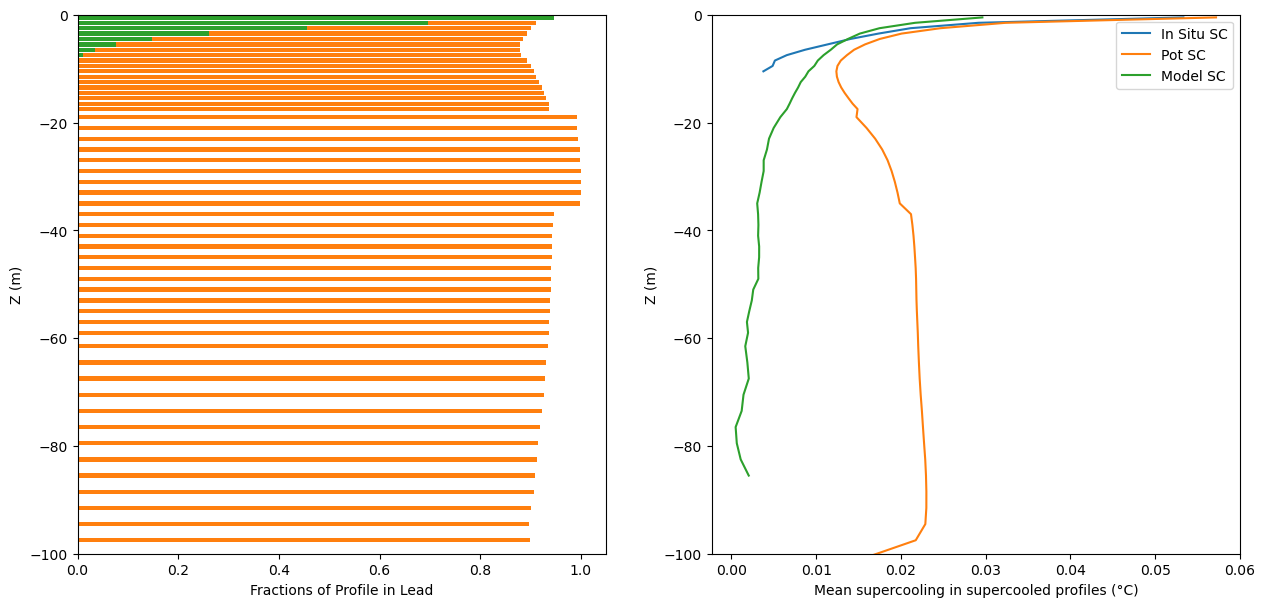

In [57]:
# Plot
filename = model_run + "_SC_depth_stats.nc"
SC_depth_stats = xr.open_dataset(filename)

fig, ax = plt.subplots(1,2, figsize = (15,7))

# Plot Supercooling Fractions
ax[0].barh(SC_depth_stats.Z, SC_depth_stats.modelSC_frac, label = "Model SC")
ax[0].barh(SC_depth_stats.Z, SC_depth_stats.potSC_frac, label = "Pot SC")
ax[0].barh(SC_depth_stats.Z, SC_depth_stats.insituSC_frac, label = "In Situ SC")



ax[0].set_xlabel("Fractions of Profile in Lead")
ax[0].set_ylabel("Z (m)")


# plot mean supercooling
ax[1].plot(SC_depth_stats.insituSC_mean_positive, SC_depth_stats.Z, label = "In Situ SC")
ax[1].plot(SC_depth_stats.potSC_mean_positive, SC_depth_stats.Z, label = "Pot SC")
ax[1].plot(SC_depth_stats.modelSC_mean_positive, SC_depth_stats.Z, label = "Model SC")

ax[1].set_xlabel("Mean supercooling in supercooled profiles (°C)")
ax[1].set_ylabel("Z (m)")


for a in ax:
    a.set_ylim(-100,0)

plt.legend()

